# Case 6 Report

Метрические методы регрессии: Nadaraya-Watson и LOWESS.

Проверяем:
- выбор ядра и ширины окна;
- fixed vs variable window;
- робастность LOWESS к выбросам;
- качество на реальных датасетах.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from case_6.experiments import (
    kernel_vs_window_impact,
    lowess_diagnostic_artifacts,
    lowess_outlier_threshold_study,
    run_real_dataset_benchmark,
    run_synthetic_comparison,
    synthetic_curve_artifacts,
    variable_vs_fixed_win_map,
)


In [2]:
synthetic = run_synthetic_comparison(seed=42)
{k: (v.mae, v.rmse, v.r2) for k, v in synthetic.items()}


{'nw_fixed': (0.25431730575982564, 0.6494482757243141, 0.5955950365147342),
 'nw_variable': (0.25721237740722874, 0.6527701883736581, 0.5914474123282055),
 'lowess': (0.23406463696764812, 0.6389463653999722, 0.6085681601328456)}

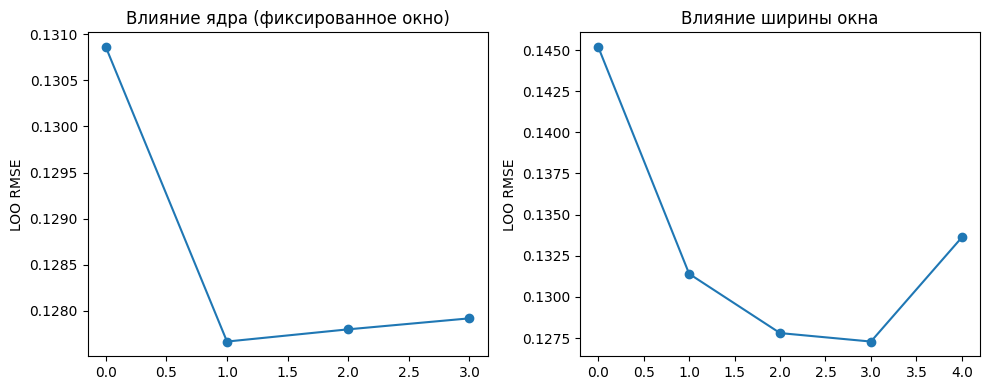

In [3]:
impact = kernel_vs_window_impact(seed=42)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(impact['kernel_rmse'], marker='o')
plt.title('Влияние ядра (фиксированное окно)')
plt.ylabel('LOO RMSE')

plt.subplot(1, 2, 2)
plt.plot(impact['window_rmse'], marker='o')
plt.title('Влияние ширины окна')
plt.ylabel('LOO RMSE')
plt.tight_layout()


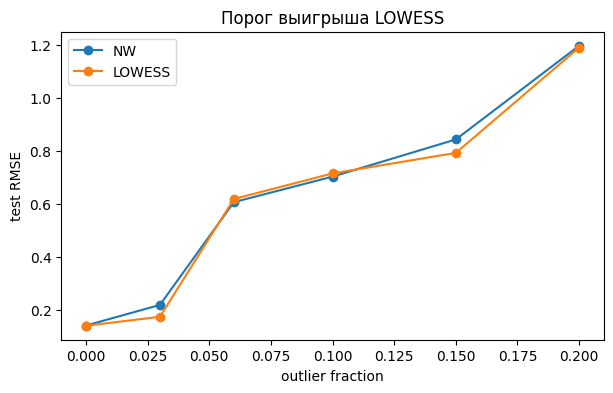

In [4]:
threshold = lowess_outlier_threshold_study(seed=42)
levels = [x[0] for x in threshold]
nw_rmse = [x[1] for x in threshold]
lowess_rmse = [x[2] for x in threshold]

plt.figure(figsize=(7, 4))
plt.plot(levels, nw_rmse, marker='o', label='NW')
plt.plot(levels, lowess_rmse, marker='o', label='LOWESS')
plt.xlabel('outlier fraction')
plt.ylabel('test RMSE')
plt.title('Порог выигрыша LOWESS')
plt.legend()


In [5]:
real_bench = run_real_dataset_benchmark(seed=42)
for name, scores in real_bench.items():
    print(name)
    for method, metric in scores.items():
        print(' ', method, metric)


diabetes
  nw_fixed EvalMetrics(mae=47.629505390050625, rmse=57.90104798151783, r2=0.4598269714684151)
  nw_variable EvalMetrics(mae=46.424503226496405, rmse=58.20930230023574, r2=0.45406010159285926)
  lowess EvalMetrics(mae=48.680165364313986, rmse=59.62425675822865, r2=0.4271960505437329)
california
  nw_fixed EvalMetrics(mae=0.4882493579485959, rmse=0.679014719338796, r2=0.6436641735952847)
  nw_variable EvalMetrics(mae=0.4911366716876269, rmse=0.6740457929628381, r2=0.6488603141851097)
  lowess EvalMetrics(mae=0.5083226019496372, rmse=0.719628215157719, r2=0.5997627765947182)


Text(0, 0.5, 'y')

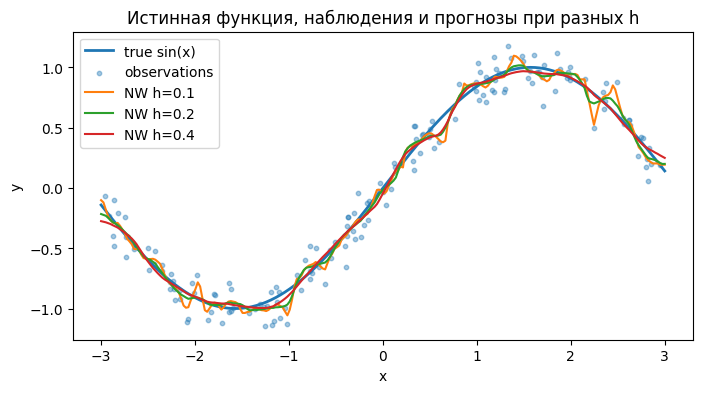

In [6]:
curve = synthetic_curve_artifacts(h_values=[0.1, 0.2, 0.4], k_values=[5, 10, 15], seed=42)

plt.figure(figsize=(8, 4))
plt.plot(curve['x_line'], curve['y_true_line'], label='true sin(x)', linewidth=2)
plt.scatter(curve['x_train'], curve['y_train'], s=10, alpha=0.4, label='observations')
for i, h in enumerate([0.1, 0.2, 0.4]):
    plt.plot(curve['x_line'], curve['pred_by_h'][i], label=f'NW h={h}')
plt.legend()
plt.title('Истинная функция, наблюдения и прогнозы при разных h')
plt.xlabel('x')
plt.ylabel('y')


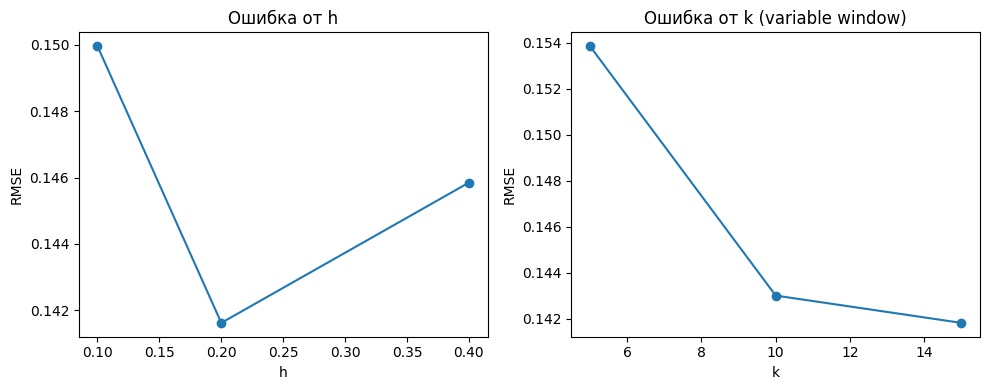

In [7]:
h_values = [0.1, 0.2, 0.4]
k_values = [5, 10, 15]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(h_values, curve['rmse_by_h'], marker='o')
plt.title('Ошибка от h')
plt.xlabel('h')
plt.ylabel('RMSE')

plt.subplot(1, 2, 2)
plt.plot(k_values, curve['rmse_by_k'], marker='o')
plt.title('Ошибка от k (variable window)')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.tight_layout()


Text(0, 0.5, 'gamma')

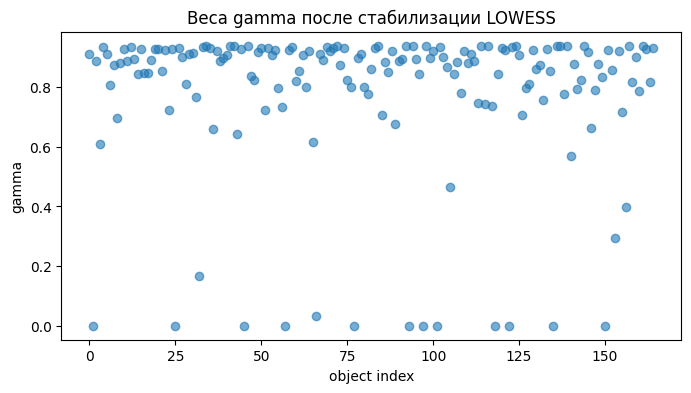

In [8]:
diag = lowess_diagnostic_artifacts(seed=42)
order = np.argsort(diag['x_train'])

plt.figure(figsize=(8, 4))
plt.plot(np.arange(diag['gamma'].size), diag['gamma'], marker='o', linestyle='none', alpha=0.6)
plt.title('Веса gamma после стабилизации LOWESS')
plt.xlabel('object index')
plt.ylabel('gamma')


Text(0, 0.5, 'y')

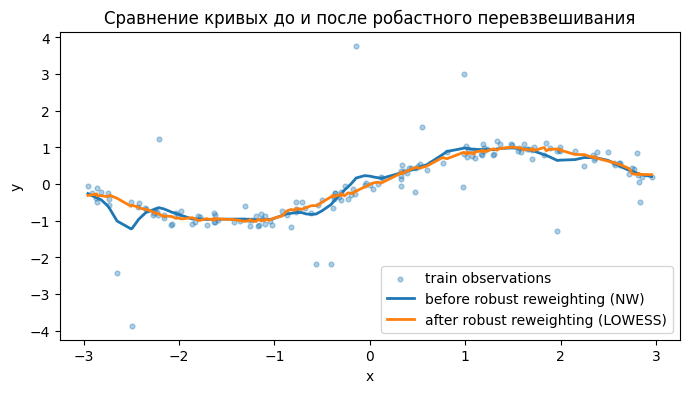

In [9]:
from case_6.nadaraya_watson import nw_predict_fixed

nw_before = nw_predict_fixed(diag['x_train'][:, None], diag['y_train'], diag['x_train'][:, None], h=0.3, kernel_name='triangular')

plt.figure(figsize=(8, 4))
plt.scatter(diag['x_train'], diag['y_train'], s=12, alpha=0.35, label='train observations')
plt.plot(diag['x_train'][order], nw_before[order], linewidth=2, label='before robust reweighting (NW)')
plt.plot(diag['x_train'][order], diag['lowess_train_pred'][order], linewidth=2, label='after robust reweighting (LOWESS)')
plt.legend()
plt.title('Сравнение кривых до и после робастного перевзвешивания')
plt.xlabel('x')
plt.ylabel('y')


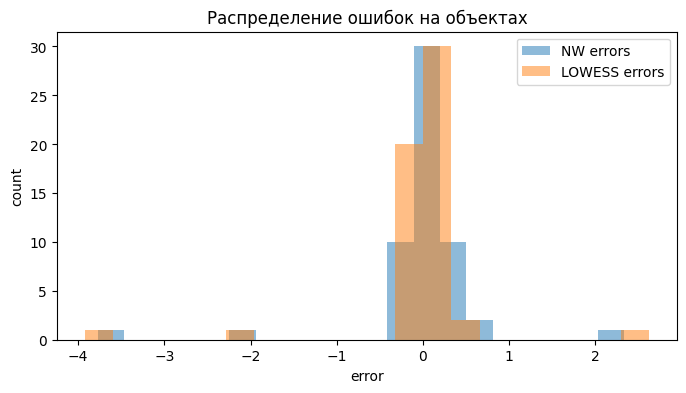

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(diag['test_err_nw'], bins=20, alpha=0.5, label='NW errors')
plt.hist(diag['test_err_lowess'], bins=20, alpha=0.5, label='LOWESS errors')
plt.title('Распределение ошибок на объектах')
plt.xlabel('error')
plt.ylabel('count')
plt.legend()


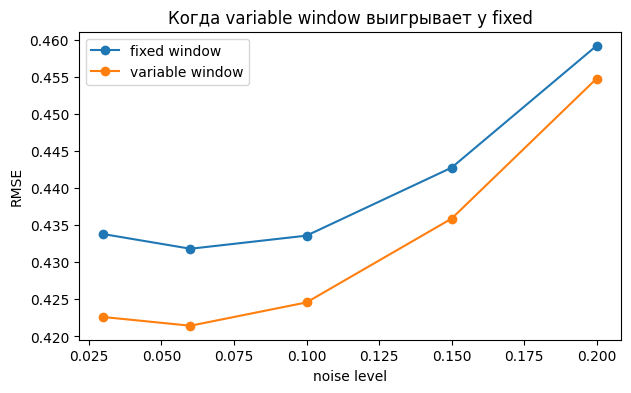

In [11]:
win_map = variable_vs_fixed_win_map([0.03, 0.06, 0.1, 0.15, 0.2], seed=42)
noise = [r[0] for r in win_map]
rmse_fixed = [r[1] for r in win_map]
rmse_variable = [r[2] for r in win_map]

plt.figure(figsize=(7, 4))
plt.plot(noise, rmse_fixed, marker='o', label='fixed window')
plt.plot(noise, rmse_variable, marker='o', label='variable window')
plt.xlabel('noise level')
plt.ylabel('RMSE')
plt.title('Когда variable window выигрывает у fixed')
plt.legend()
